
# Predicting Water Well Failures in Tanzania

## Business Understanding

Access to clean water is a major challenge in Tanzania, where many wells are either non-functional or in need of repair.
This project builds a classification model to predict well condition and identify the factors most associated with failure.

### Stakeholders
- Government agencies responsible for water infrastructure
- NGOs coordinating well repairs and rural water access

### Business Question
Can we predict the operational status of a water well using available information such as region, extraction system, and age?



## Data Understanding

This notebook uses the Tanzanian Water Wells training datasets:
- training features
- training labels

The target variable is **`status_group`**, which has three classes:
- `functional`
- `functional needs repair`
- `non functional`


In [29]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False
})
sns.set_style("whitegrid")


In [30]:

# Load the training data
X_train_raw = pd.read_csv("data/4910797b-ee55-40a7-8668-10efd5c1b960.csv")
y_train_raw = pd.read_csv("data/0bf8bc6e-30d0-4c50-956a-603fc693d966.csv")

# Merge features and labels
df = X_train_raw.merge(y_train_raw, on="id")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (59400, 41)


,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,...,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,...,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,...,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,...,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,...,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional


In [31]:

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 59400 entries, 0 to 59399
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     59400 non-null  int64  
 1   amount_tsh             59400 non-null  float64
 2   date_recorded          59400 non-null  str    
 3   funder                 55763 non-null  str    
 4   gps_height             59400 non-null  int64  
 5   installer              55745 non-null  str    
 6   longitude              59400 non-null  float64
 7   latitude               59400 non-null  float64
 8   wpt_name               59398 non-null  str    
 9   num_private            59400 non-null  int64  
 10  basin                  59400 non-null  str    
 11  subvillage             59029 non-null  str    
 12  region                 59400 non-null  str    
 13  region_code            59400 non-null  int64  
 14  district_code          59400 non-null  int64  
 15  lga          

In [32]:

df.isna().sum().sort_values(ascending=False).head(20)


scheme_name          28810
scheme_management     3878
installer             3655
funder                3637
public_meeting        3334
permit                3056
subvillage             371
wpt_name                 2
id                       0
latitude                 0
longitude                0
date_recorded            0
gps_height               0
amount_tsh               0
num_private              0
basin                    0
region                   0
ward                     0
lga                      0
district_code            0
dtype: int64


### Initial Observations

- The dataset contains both numerical and categorical variables.
- Missing values are concentrated in several location and scheme-related columns.
- The target is multiclass, so this is a three-class classification problem.


## Data Preparation

In [33]:

# Drop low-value columns
df = df.drop(columns=["id", "recorded_by", "num_private"], errors="ignore")

# Parse dates and engineer age-related features
df["date_recorded"] = pd.to_datetime(df["date_recorded"], errors="coerce")
df["recorded_year"] = df["date_recorded"].dt.year
df["recorded_month"] = df["date_recorded"].dt.month

df["construction_year"] = pd.to_numeric(df["construction_year"], errors="coerce")
df.loc[df["construction_year"] == 0, "construction_year"] = np.nan

df["well_age"] = df["recorded_year"] - df["construction_year"]
df.loc[df["well_age"] < 0, "well_age"] = np.nan

# Drop the raw date once derivative features are created
df = df.drop(columns=["date_recorded"], errors="ignore")

# Fill missing values:
# - numeric columns -> median
# - categorical columns -> "Unknown"
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != "status_group"]

categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
categorical_cols = [c for c in categorical_cols if c != "status_group"]

df[numeric_cols] = df[numeric_cols].apply(lambda col: col.fillna(col.median()))
df[categorical_cols] = df[categorical_cols].fillna("Unknown")

df[["construction_year", "well_age", "recorded_year", "recorded_month"]].head()


,construction_year,well_age,recorded_year,recorded_month
0,1999.0,12.0,2011,3
1,2010.0,3.0,2013,3
2,2009.0,4.0,2013,2
3,1986.0,27.0,2013,1
4,2000.0,13.0,2011,7


## Exploratory Data Analysis

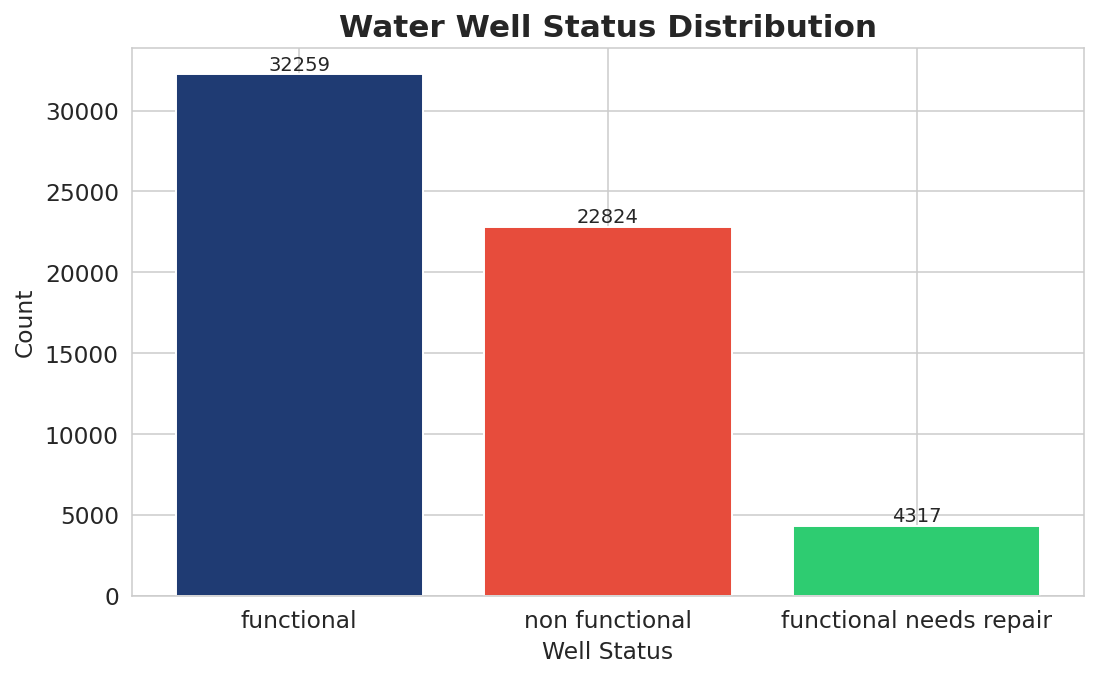

In [34]:

counts = df["status_group"].value_counts()

plt.figure(figsize=(8, 5))
bars = plt.bar(counts.index, counts.values, color=["#1f3b73", "#e74c3c", "#2ecc71"])

plt.title("Water Well Status Distribution", fontweight="bold")
plt.xlabel("Well Status")
plt.ylabel("Count")

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{int(bar.get_height())}",
             ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig("data/status_distribution.png")
plt.show()



### Insight
Most wells are functional, but a large number are non-functional.
This class imbalance matters because a model could appear accurate while still performing poorly on failed wells.


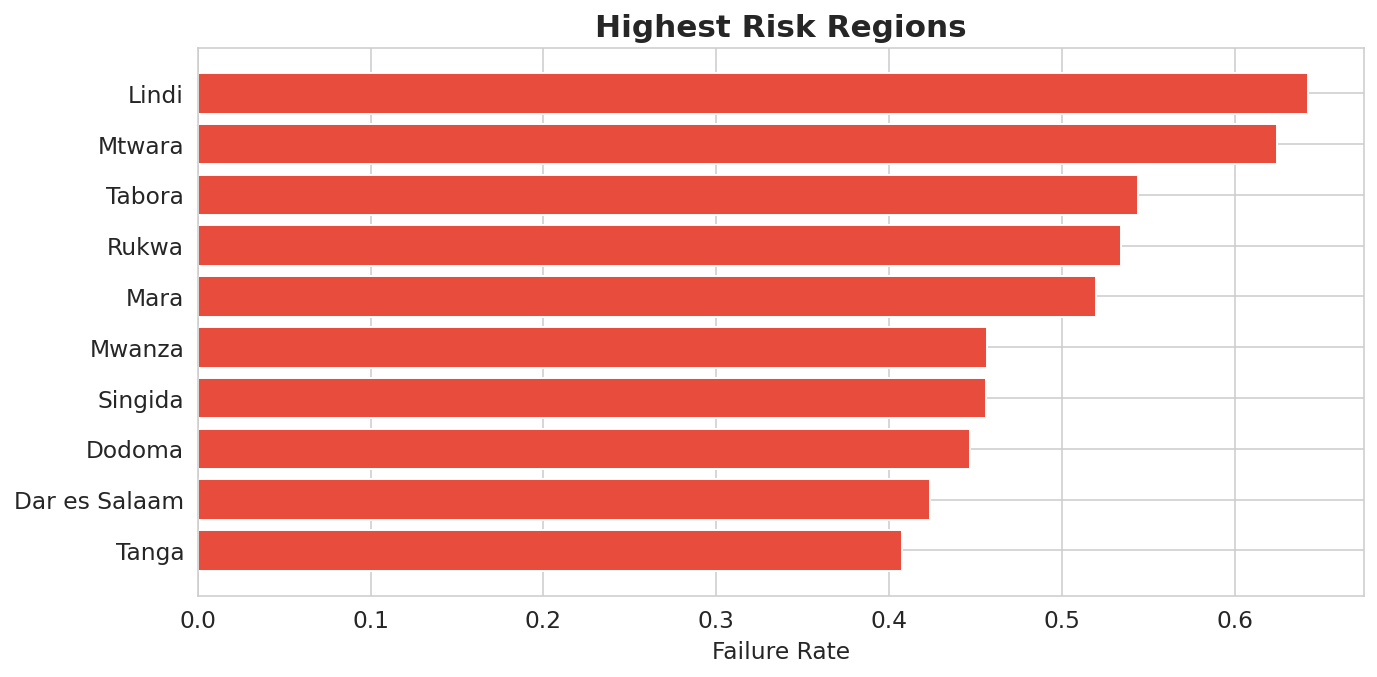

In [35]:

region_fail = df.groupby("region")["status_group"].value_counts(normalize=True).unstack()

top_regions = region_fail["non functional"].sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.barh(top_regions.index, top_regions.values, color="#e74c3c")
plt.title("Highest Risk Regions", fontweight="bold")
plt.xlabel("Failure Rate")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("data/region_failure.png")
plt.show()



### Insight
Failure rates vary substantially across regions.
This suggests that environmental conditions, local governance, or infrastructure quality differ meaningfully by geography.


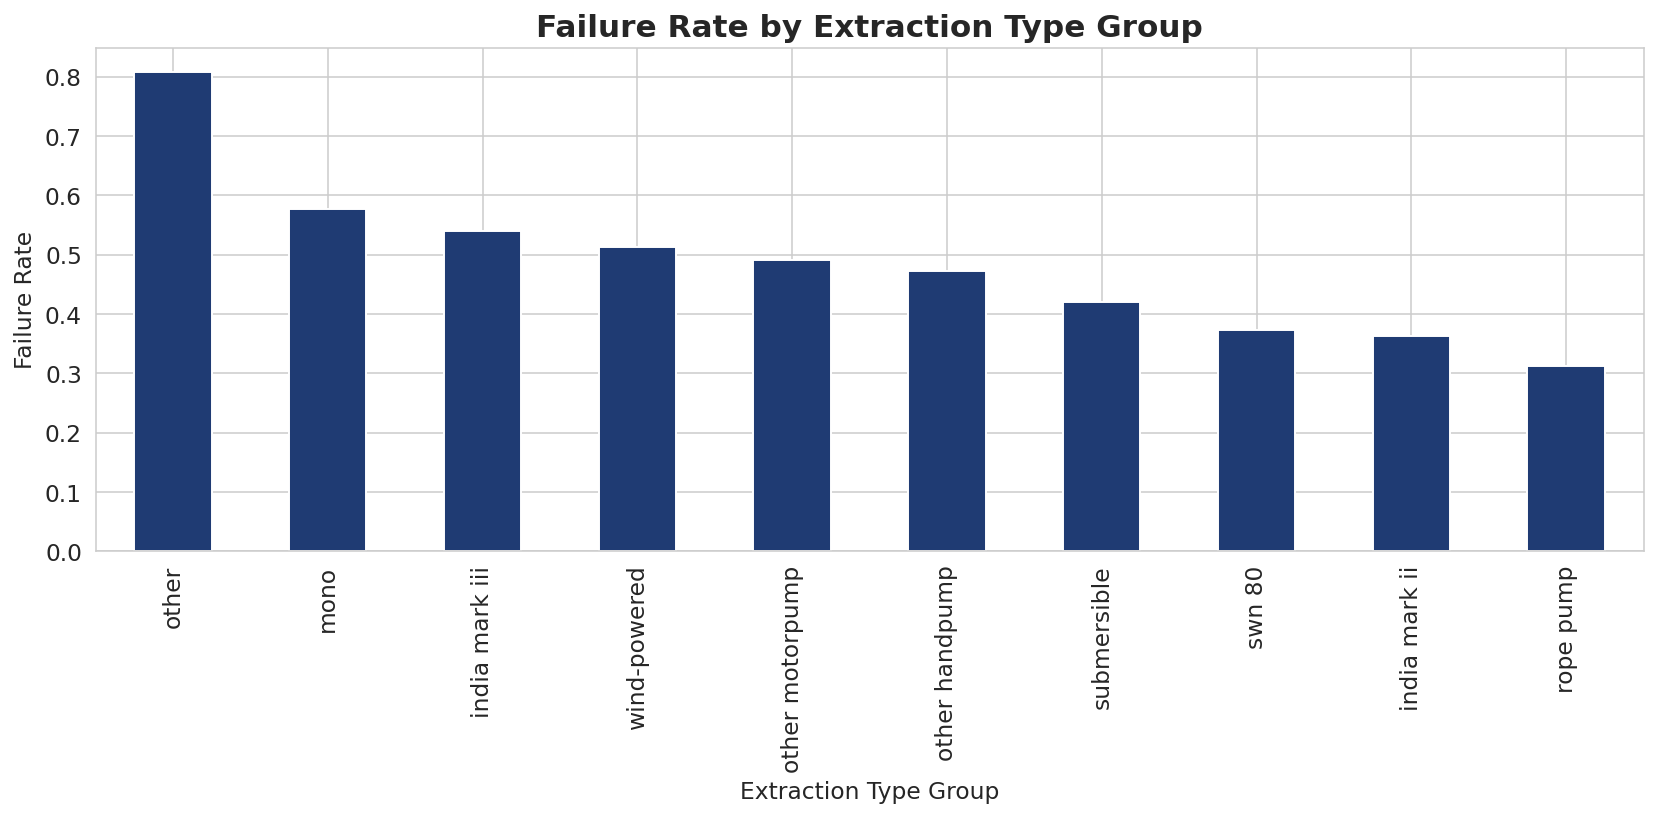

In [36]:

pump_fail = df.groupby("extraction_type_group")["status_group"].value_counts(normalize=True).unstack()

top_pumps = pump_fail["non functional"].sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_pumps.plot(kind="bar", color="#1f3b73")
plt.title("Failure Rate by Extraction Type Group", fontweight="bold")
plt.ylabel("Failure Rate")
plt.xlabel("Extraction Type Group")
plt.tight_layout()
plt.savefig("data/pump_failure.png")
plt.show()



### Insight
Some extraction systems are associated with much higher failure rates.
That points to differences in installation quality, technical suitability, or long-term durability.


/tmp/ipykernel_276654/2865968766.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="status_group", y="well_age", palette=["#2ecc71", "#1f3b73", "#e74c3c"])


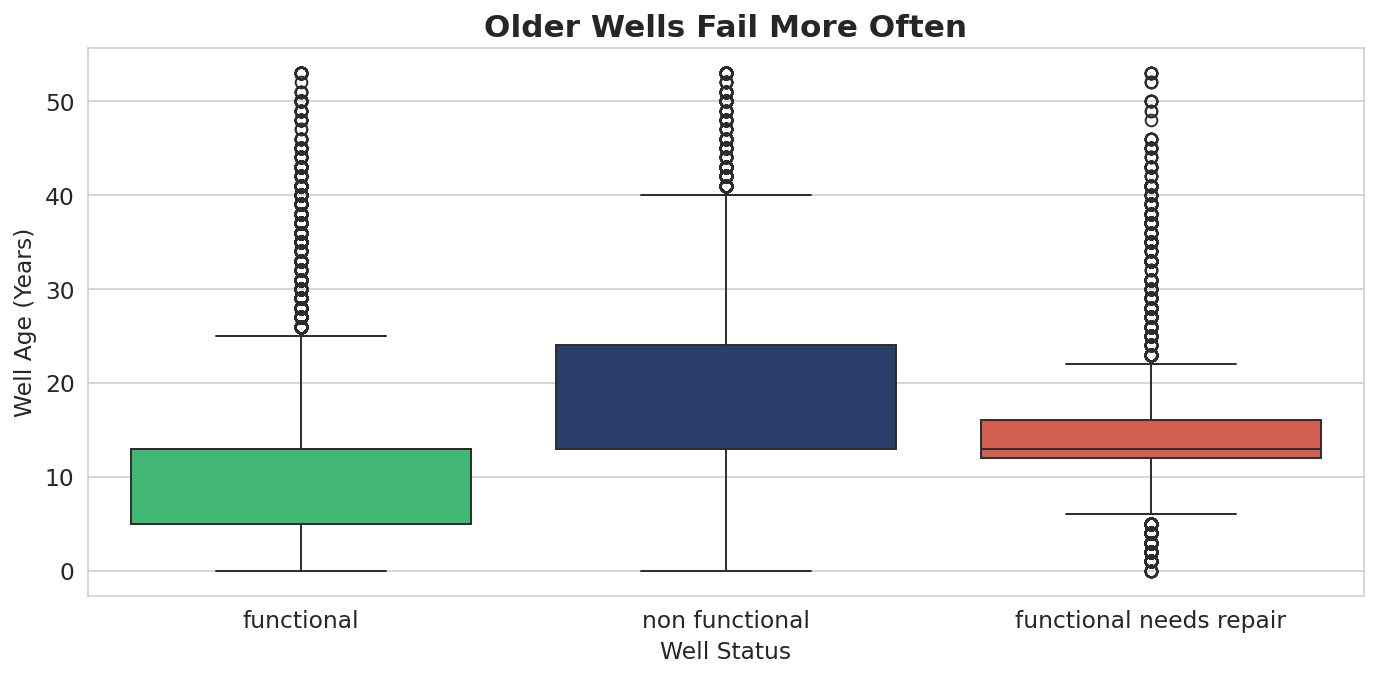

In [37]:

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="status_group", y="well_age", palette=["#2ecc71", "#1f3b73", "#e74c3c"])
plt.title("Older Wells Fail More Often", fontweight="bold")
plt.xlabel("Well Status")
plt.ylabel("Well Age (Years)")
plt.tight_layout()
plt.savefig("data/age_vs_status.png")
plt.show()



### Insight
Older wells tend to be more strongly associated with non-functional status.
This supports the case for proactive maintenance and lifecycle-based intervention.



## Feature Engineering and Encoding

The target is separated **before** encoding so it is not accidentally converted into dummy variables.
To keep the notebook stable and avoid memory issues, a few very high-cardinality columns are dropped before one-hot encoding.


In [38]:
y = df["status_group"]

high_cardinality_cols = ["funder", "installer", "wpt_name", "subvillage", "ward", "scheme_name", "lga"]

X = df.drop(columns=["status_group"] + high_cardinality_cols, errors="ignore")

X_encoded = pd.get_dummies(X, drop_first=True)

print("Encoded feature matrix shape:", X_encoded.shape)

X_train, X_val, y_train, y_val = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)


Encoded feature matrix shape: (59400, 164)
Training shape: (47520, 164)
Validation shape: (11880, 164)


## Modeling

In [39]:

# Baseline model for reference
dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(X_train, y_train)
y_pred_dummy = dummy_model.predict(X_val)

# Decision Tree
dt_model = DecisionTreeClassifier(max_depth=15, min_samples_leaf=5, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_val)

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=40,
    max_depth=16,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_val)


In [40]:

print("Dummy Baseline Accuracy:", accuracy_score(y_val, y_pred_dummy))
print("Decision Tree Accuracy:", accuracy_score(y_val, y_pred_dt))
print("Random Forest Accuracy:", accuracy_score(y_val, y_pred_rf))


Dummy Baseline Accuracy: 0.5430976430976431
Decision Tree Accuracy: 0.7697811447811448
Random Forest Accuracy: 0.7914141414141415


In [41]:

print("Random Forest Classification Report")
print(classification_report(y_val, y_pred_rf))


Random Forest Classification Report
                         precision    recall  f1-score   support

             functional       0.76      0.93      0.84      6452
functional needs repair       0.68      0.15      0.24       863
         non functional       0.85      0.72      0.78      4565

               accuracy                           0.79     11880
              macro avg       0.76      0.60      0.62     11880
           weighted avg       0.79      0.79      0.77     11880




### Modeling Insight
The Random Forest model outperforms both the baseline and the single Decision Tree.
This indicates that well condition depends on nonlinear interactions among multiple features.


## Feature Importance

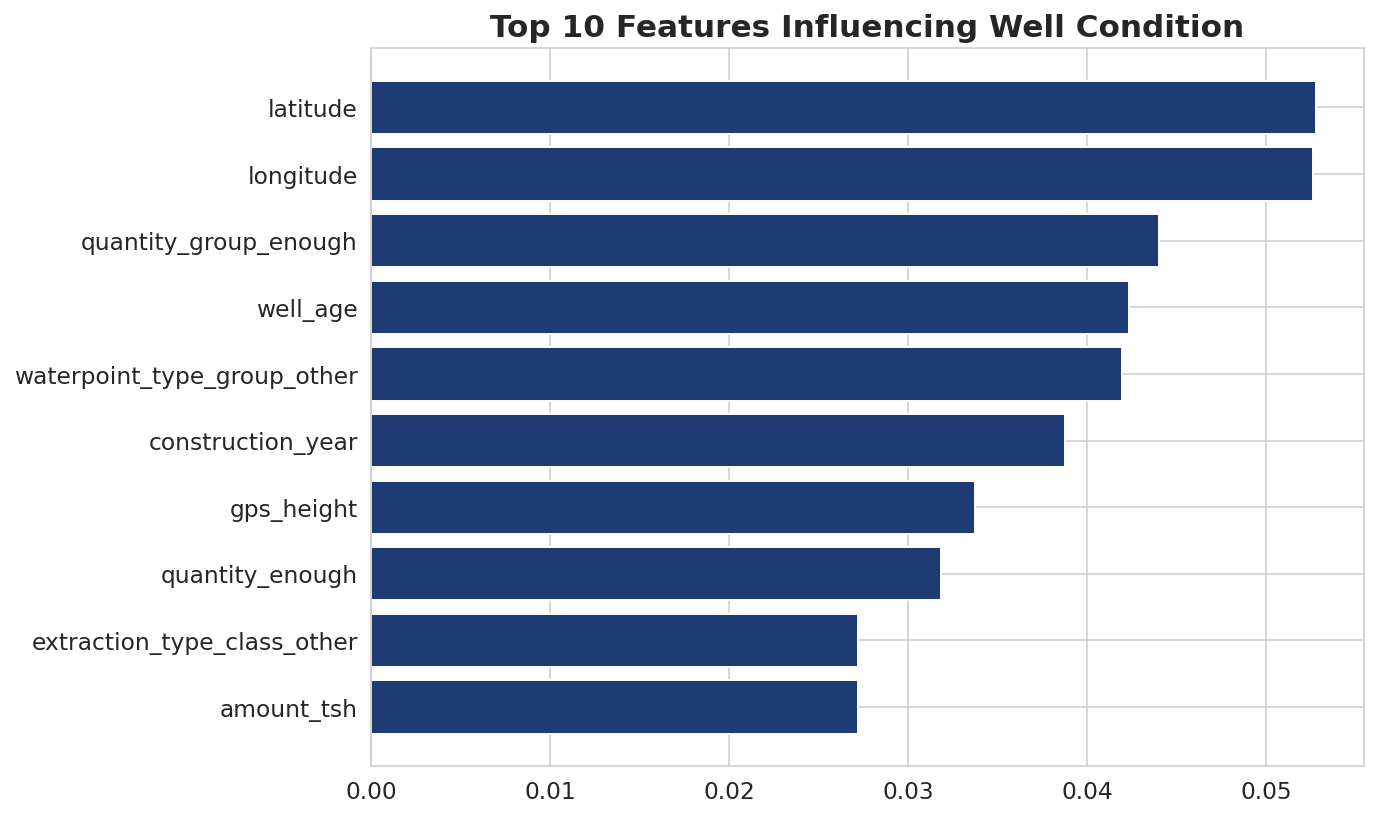

In [42]:

feature_importance = pd.Series(rf_model.feature_importances_, index=X_encoded.columns)
top_features = feature_importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features.index[::-1], top_features.values[::-1], color="#1f3b73")
plt.title("Top 10 Features Influencing Well Condition", fontweight="bold")
plt.tight_layout()
plt.savefig("data/feature_importance.png")
plt.show()



### Insight
The most important predictors align with the exploratory analysis:
- well age
- region/location indicators
- extraction system characteristics

That consistency strengthens confidence in the analysis.


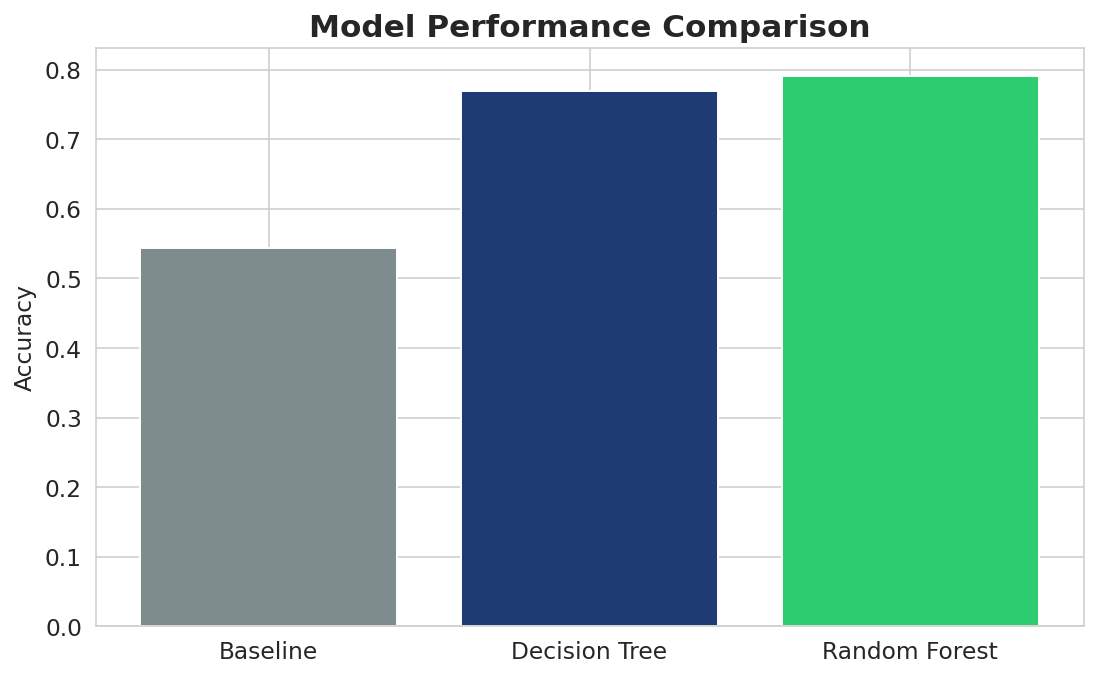

In [43]:

models = ["Baseline", "Decision Tree", "Random Forest"]
scores = [
    accuracy_score(y_val, y_pred_dummy),
    accuracy_score(y_val, y_pred_dt),
    accuracy_score(y_val, y_pred_rf)
]

plt.figure(figsize=(8, 5))
plt.bar(models, scores, color=["#7f8c8d", "#1f3b73", "#2ecc71"])
plt.title("Model Performance Comparison", fontweight="bold")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.savefig("data/model_comparison.png")
plt.show()


## Evaluation


The analysis shows that water well condition can be predicted meaningfully from available infrastructure and location data.

### Strengths
- The project addresses a real, socially important business problem.
- The model captures clear signals related to age, region, and extraction system.
- The final Random Forest model meaningfully outperforms the baseline.

### Limitations
- Class imbalance may reduce sensitivity to minority classes.
- Missing values were handled with simple imputation rules.
- Additional maintenance-history features would likely improve performance further.


## Conclusions and Recommendations


### Key Conclusions
- Older wells are more likely to be non-functional.
- Failure rates differ significantly by region.
- Extraction system group is strongly associated with failure risk.
- Random Forest produced the strongest predictive performance among the tested models.

### Recommendations
1. Prioritize maintenance for older wells.
2. Target monitoring and repair budgets toward high-risk regions.
3. Review extraction system choices in areas with recurring failures.
4. Use predictive risk scoring to guide repair scheduling.

### Business Value
This framework can help reduce water outages, improve infrastructure planning, and support more efficient maintenance decisions.
